In [1]:
# -------------------------
# 1. PILIH VARIABEL NUMERIK
# -------------------------

fitur = [
    'pelayanan_non_rawat_inap',
    'pelayanan_rawat_inap',
    'jumlah_bidan',
    'jumlah_dokter',
    'jumlah_perawat',
    'jumlah_penyakit_tidak_menular',
    'jumlah_penyakit_menular',
    'jumlah_penduduk'
]

# -------------------------
# 2. robust SCALING
# -------------------------

from sklearn.preprocessing import RobustScaler
import pandas as pd

df = pd.read_csv('dataset_fasilitas_kesehatan_skripsi_kedua.csv')
scaler = RobustScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df[fitur]),
    columns=fitur
)

# -------------------------
# 3. GABUNGKAN DENGAN KOLOM IDENTITAS
# -------------------------

df_robust = pd.concat(
    [
        df[
            [
                'kode_provinsi',
                'nama_provinsi',
                'kode_kabupaten_kota',
                'nama_kabupaten_kota',
                'tahun'
            ]
        ].reset_index(drop=True),

        df_scaled.reset_index(drop=True)
    ],
    axis=1
)

# -------------------------
# 4. CEK HASIL
# -------------------------

print("Rata-rata setelah standarisasi:")
print(df_scaled.mean())

print("\nStandar deviasi setelah standarisasi:")
print(df_scaled.std())

display(df_robust.head())

Rata-rata setelah standarisasi:
pelayanan_non_rawat_inap         0.270677
pelayanan_rawat_inap            -0.077791
jumlah_bidan                    -0.045067
jumlah_dokter                    0.365362
jumlah_perawat                   0.367512
jumlah_penyakit_tidak_menular    0.275573
jumlah_penyakit_menular          0.743090
jumlah_penduduk                 -0.006866
dtype: float64

Standar deviasi setelah standarisasi:
pelayanan_non_rawat_inap         0.736069
pelayanan_rawat_inap             0.753170
jumlah_bidan                     0.663050
jumlah_dokter                    2.027094
jumlah_perawat                   1.636552
jumlah_penyakit_tidak_menular    0.871164
jumlah_penyakit_menular          2.602085
jumlah_penduduk                  1.027674
dtype: float64


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.484434,0.046307,-0.534189,-0.290467,-0.356782,-0.763722
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.223235,-0.006615,-0.120011,-0.258875,-0.282774,-0.194139
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.428246,0.425579,-0.341055,-0.294463,-0.359553,-0.523826
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.086560,0.584344,0.000558,0.125248,-0.271693,0.033304
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.191344,0.452040,-0.290818,-0.154862,-0.317206,0.219384


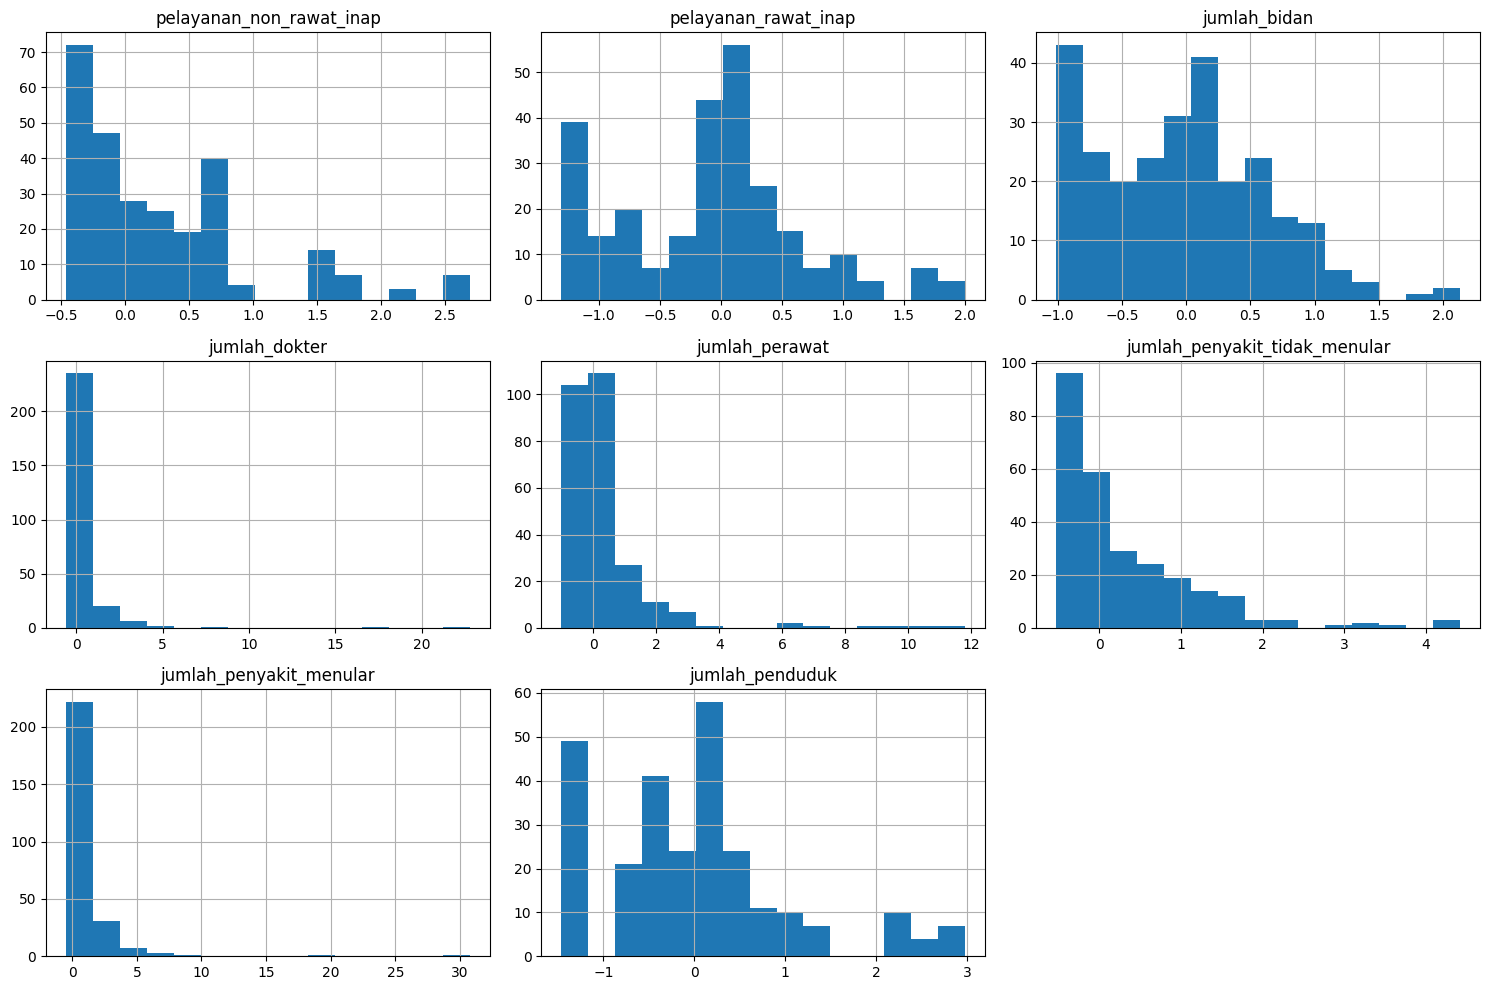

In [2]:
import matplotlib.pyplot as plt

df_scaled.hist(
    figsize=(15,10),
    bins=15
)

plt.tight_layout()
plt.show()

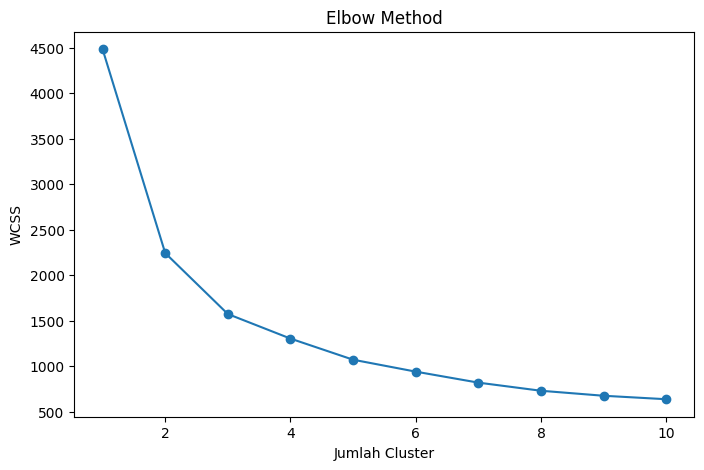

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [4]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import pandas as pd

hasil = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df_scaled)

    score = silhouette_score(df_scaled, labels)

    hasil.append([k, score])

hasil = pd.DataFrame(
    hasil,
    columns=['Jumlah Cluster', 'Silhouette Score']
)

display(hasil)

,Jumlah Cluster,Silhouette Score
0,2,0.897636
1,3,0.498316
2,4,0.437700
3,5,0.241956
4,6,0.285725
5,7,0.268393
6,8,0.264947
7,9,0.252027
8,10,0.249494


In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df_hasil = df_scaled.copy()
df_hasil['cluster'] = kmeans.fit_predict(df_scaled)

In [6]:
df_hasil['cluster'].value_counts().sort_index()

cluster
0    264
1      2
Name: count, dtype: int64

In [7]:
profil_cluster = (
    df_hasil
    .groupby('cluster')
    [
        [
            'pelayanan_non_rawat_inap',
            'pelayanan_rawat_inap',
            'jumlah_bidan',
            'jumlah_dokter',
            'jumlah_perawat',
            'jumlah_penyakit_tidak_menular',
            'jumlah_penyakit_menular',
            'jumlah_penduduk'
        ]
    ]
    .mean()
    .round(2)
)

display(profil_cluster)

,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
cluster,,,,,,,,
0,0.25,-0.08,-0.06,0.21,0.29,0.27,0.56,-0.03
1,2.69,0.38,2.04,20.34,10.56,1.41,25.00,2.92


In [8]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

silhouette = silhouette_score(
    df_scaled,
    df_hasil['cluster']
)

dbi = davies_bouldin_score(
    df_scaled,
    df_hasil['cluster']
)

chi = calinski_harabasz_score(
    df_scaled,
    df_hasil['cluster']
)

print("=== Evaluasi K-Means ===")
print(f"Silhouette Score      : {silhouette:.4f}")
print(f"Davies-Bouldin Index  : {dbi:.4f}")
print(f"Calinski-Harabasz     : {chi:.4f}")

=== Evaluasi K-Means ===
Silhouette Score      : 0.8976
Davies-Bouldin Index  : 0.2677
Calinski-Harabasz     : 263.3464


In [9]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

cluster_agglo = agglo.fit_predict(df_scaled)

df_agglo = df_scaled.copy()
df_agglo['cluster'] = cluster_agglo

df_agglo.head()

,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster
0,0.230769,-0.153846,-0.484434,0.046307,-0.534189,-0.290467,-0.356782,-0.763722,0
1,0.461538,0.153846,-0.223235,-0.006615,-0.120011,-0.258875,-0.282774,-0.194139,0
2,-0.230769,0.153846,-0.428246,0.425579,-0.341055,-0.294463,-0.359553,-0.523826,0
3,0.615385,0.076923,-0.086560,0.584344,0.000558,0.125248,-0.271693,0.033304,0
4,0.000000,0.076923,-0.191344,0.452040,-0.290818,-0.154862,-0.317206,0.219384,0


In [10]:
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import pandas as pd

# Evaluasi
silhouette = silhouette_score(df_scaled, cluster_agglo)
dbi = davies_bouldin_score(df_scaled, cluster_agglo)
chi = calinski_harabasz_score(df_scaled, cluster_agglo)

# Tabel hasil evaluasi
hasil_evaluasi = pd.DataFrame({
    'Metode': ['Agglomerative Hierarchical Clustering'],
    'Silhouette Coefficient': [round(silhouette, 4)],
    'Davies-Bouldin Index': [round(dbi, 4)],
    'Calinski-Harabasz Index': [round(chi, 4)]
})

display(hasil_evaluasi)

,Metode,Silhouette Coefficient,Davies-Bouldin Index,Calinski-Harabasz Index
0,Agglomerative Hierarchical Clustering,0.8976,0.2677,263.3464


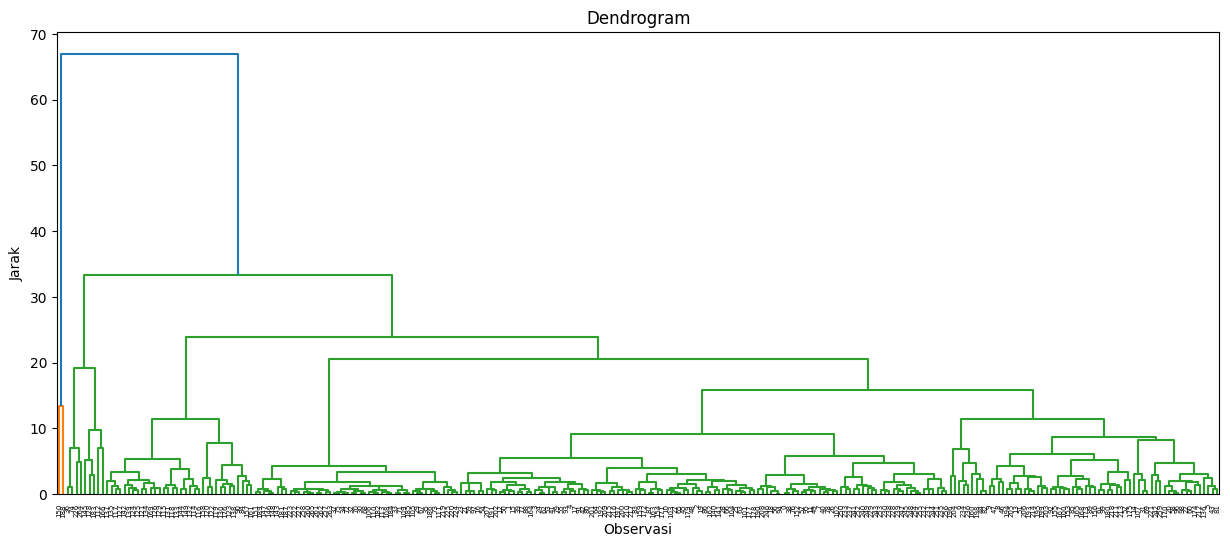

In [11]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(
    df_scaled,
    method='ward'
)

plt.figure(figsize=(15,6))

dendrogram(Z)

plt.title('Dendrogram')
plt.xlabel('Observasi')
plt.ylabel('Jarak')
plt.show()

In [12]:
profil_agglo = (
    df_agglo
    .groupby('cluster')
    [
        [
            'pelayanan_non_rawat_inap',
            'pelayanan_rawat_inap',
            'jumlah_bidan',
            'jumlah_dokter',
            'jumlah_perawat',
            'jumlah_penyakit_tidak_menular',
            'jumlah_penyakit_menular',
            'jumlah_penduduk'
        ]
    ]
    .mean()
    .round(2)
)

display(profil_agglo)

,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
cluster,,,,,,,,
0,0.25,-0.08,-0.06,0.21,0.29,0.27,0.56,-0.03
1,2.69,0.38,2.04,20.34,10.56,1.41,25.00,2.92


In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import pandas as pd

hasil_evaluasi = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df_scaled)

    silhouette = silhouette_score(df_scaled, labels)
    dbi = davies_bouldin_score(df_scaled, labels)
    chi = calinski_harabasz_score(df_scaled, labels)

    hasil_evaluasi.append([
        k,
        round(silhouette, 4),
        round(dbi, 4),
        round(chi, 4)
    ])

hasil_evaluasi = pd.DataFrame(
    hasil_evaluasi,
    columns=[
        'Jumlah Cluster',
        'Silhouette Score',
        'Davies-Bouldin Index',
        'Calinski-Harabasz Index'
    ]
)

display(hasil_evaluasi)

,Jumlah Cluster,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.8976,0.2677,263.3464
1,3,0.4983,0.9480,242.8443
2,4,0.4377,0.9352,212.6748
3,5,0.2420,1.0597,207.3457
4,6,0.2857,1.0471,195.4483
5,7,0.2684,1.0787,192.4586
6,8,0.2649,0.9280,188.8258
7,9,0.2520,1.0185,180.5488
8,10,0.2495,0.9287,171.0805


In [14]:
print("Cluster terbaik berdasarkan Silhouette:")
display(
    hasil_evaluasi.loc[
        hasil_evaluasi['Silhouette Score'].idxmax()
    ]
)

print("\nCluster terbaik berdasarkan DBI:")
display(
    hasil_evaluasi.loc[
        hasil_evaluasi['Davies-Bouldin Index'].idxmin()
    ]
)

print("\nCluster terbaik berdasarkan CHI:")
display(
    hasil_evaluasi.loc[
        hasil_evaluasi['Calinski-Harabasz Index'].idxmax()
    ]
)

Cluster terbaik berdasarkan Silhouette:


Jumlah Cluster               2.0000
Silhouette Score             0.8976
Davies-Bouldin Index         0.2677
Calinski-Harabasz Index    263.3464
Name: 0, dtype: float64


Cluster terbaik berdasarkan DBI:


Jumlah Cluster               2.0000
Silhouette Score             0.8976
Davies-Bouldin Index         0.2677
Calinski-Harabasz Index    263.3464
Name: 0, dtype: float64


Cluster terbaik berdasarkan CHI:


Jumlah Cluster               2.0000
Silhouette Score             0.8976
Davies-Bouldin Index         0.2677
Calinski-Harabasz Index    263.3464
Name: 0, dtype: float64